# Data Preprocessing
* Lowercasing
* Tokenization
* Punctuation removal
* Stop word removal
* Lemmatization
--> Save prerpocessed data as pickle

## Install & Import

In [ ]:
import kagglehub
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import re
import unicodedata
import html

from langdetect import detect

import spacy

## Load & Inspect

In [2]:
# Download latest version of the data set
path = kagglehub.dataset_download("sumitm004/reddit-raskscience-flair-dataset")

In [3]:
# Load data (relevant columns only)
df = pd.read_csv(f"{path}/flair_data.csv", usecols=[0, 1, 4, 5, 6, 7, 9, 10, 12])
df.head()

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,NaN,2016-07-03 06:40:06,2016,2016-09-02 17:31:58
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09


In [4]:
# Inspect data
print(df.shape)
print()
print(df.columns.tolist())
print()
print(df.info())
print()
df.describe()

(612668, 9)

['id', 'author', 'question', 'link_flair_css_class', 'link_flair_text', 'description', 'created_utc', 'year', 'retrieved_on']

<class 'pandas.DataFrame'>
RangeIndex: 612668 entries, 0 to 612667
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   id                    612668 non-null  str  
 1   author                612668 non-null  str  
 2   question              612668 non-null  str  
 3   link_flair_css_class  612668 non-null  str  
 4   link_flair_text       612668 non-null  str  
 5   description           594447 non-null  str  
 6   created_utc           612668 non-null  str  
 7   year                  612668 non-null  int64
 8   retrieved_on          612668 non-null  str  
dtypes: int64(1), str(8)
memory usage: 42.1 MB
None



,year
count,612668.000000
mean,2018.690172
std,1.905706
min,2016.000000
25%,2017.000000
50%,2019.000000
75%,2020.000000
max,2022.000000


## Saving Raw Data

In [5]:
# Save lemmatized df to pickle file
df.to_pickle("data/raw_data.pkl")

## Data Quality Assessment

### Handling Missing Values

In [6]:
# List the number of missing values per column
df.isnull().sum()

id                          0
author                      0
question                    0
link_flair_css_class        0
link_flair_text             0
description             18221
created_utc                 0
year                        0
retrieved_on                0
dtype: int64

In [7]:
df['description'] = df['description'].fillna("")
df.isna().sum()

id                      0
author                  0
question                0
link_flair_css_class    0
link_flair_text         0
description             0
created_utc             0
year                    0
retrieved_on            0
dtype: int64

No completely missing values. Some posts don't have a description. Filling in an empty string will get the issue handled during preprocessing for NLP.


### Handling Duplicates

In [8]:
df[['question', 'description', 'author']].duplicated().sum()

np.int64(6093)

In [9]:
df[df[['question', 'description', 'author']].duplicated()]

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on
95,4r8bju,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:42:55,2016,2016-09-03 18:05:47
133,4rchtp,[deleted],What's the physics behind this rainbow paper h...,physics,Physics,[removed],2016-07-05 12:45:50,2016,2016-09-03 18:41:59
421,4qxojf,Khovansky,How do Helmet shells form?,bio,Biology,[removed],2016-07-02 15:38:11,2016,2016-09-02 17:01:24
1114,4vixxa,psycommander,"Are silicon ingots, wafers, and IC dies, huge ...",chem,Chemistry,"Because in these kind of silicon structures, a...",2016-07-31 20:47:28,2016,2016-09-04 16:08:52
1227,4tx89f,[deleted],How do we know what the bee population is arou...,bio,Biology,[removed],2016-07-21 14:27:58,2016,2016-09-04 07:57:13
...,...,...,...,...,...,...,...,...,...
612655,ry6z73,Flobber7,2 doses of vaccines protect against severe ill...,med,COVID-19,[removed],2022-01-07 13:06:28,2022,2022-01-07 13:06:39
612658,ry6wio,Flobber7,2 doses of vaccines protect against severe ill...,med,COVID-19,[removed],2022-01-07 13:02:21,2022,2022-01-07 13:02:31
612659,ry6v7u,Flobber7,2 doses of vaccines protect against severe ill...,med,COVID-19,[removed],2022-01-07 13:00:28,2022,2022-01-07 13:00:40
612660,ry6t9p,Flobber7,2 doses of vaccines protect against severe ill...,med,COVID-19,[removed],2022-01-07 12:57:34,2022,2022-01-07 12:57:45


Entries with duplicated question, description, and author are dropped.

In [10]:
df = df.drop_duplicates(subset=['question', 'description', 'author'])
df

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09
...,...,...,...,...,...,...,...,...,...
612663,ry6of6,Dr_HanibalLecter,Dentists! I've got a question for you: why do ...,med,Medicine,[removed],2022-01-07 12:49:34,2022,2022-01-07 12:49:44
612664,ry6nvu,matew312,Why did we evolve to have consciousness?,bio,Biology,[removed],2022-01-07 12:48:42,2022,2022-01-07 12:48:52
612665,ry6nle,Unique-horny,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,[removed],2022-01-07 12:48:11,2022,2022-01-07 12:48:22
612666,rwkxsm,jallen11altnagelvin,Would tracing paper be classed as translucent ...,physics,Physics,[removed],2022-01-05 11:37:15,2022,2022-01-05 11:37:26


## Exploration & Summary
The data set contains 603,300 Reddit posts published in r/askscience from 2016 to 2022. To get a quick overview, the distribution of posts across css_classes is examined.
### Colors, Styles & Presets

In [11]:
# Plot style
sns.set_theme(style='whitegrid', context='paper')

### Distribution across Categories

In [12]:
len(df['link_flair_css_class'].unique().tolist())

16

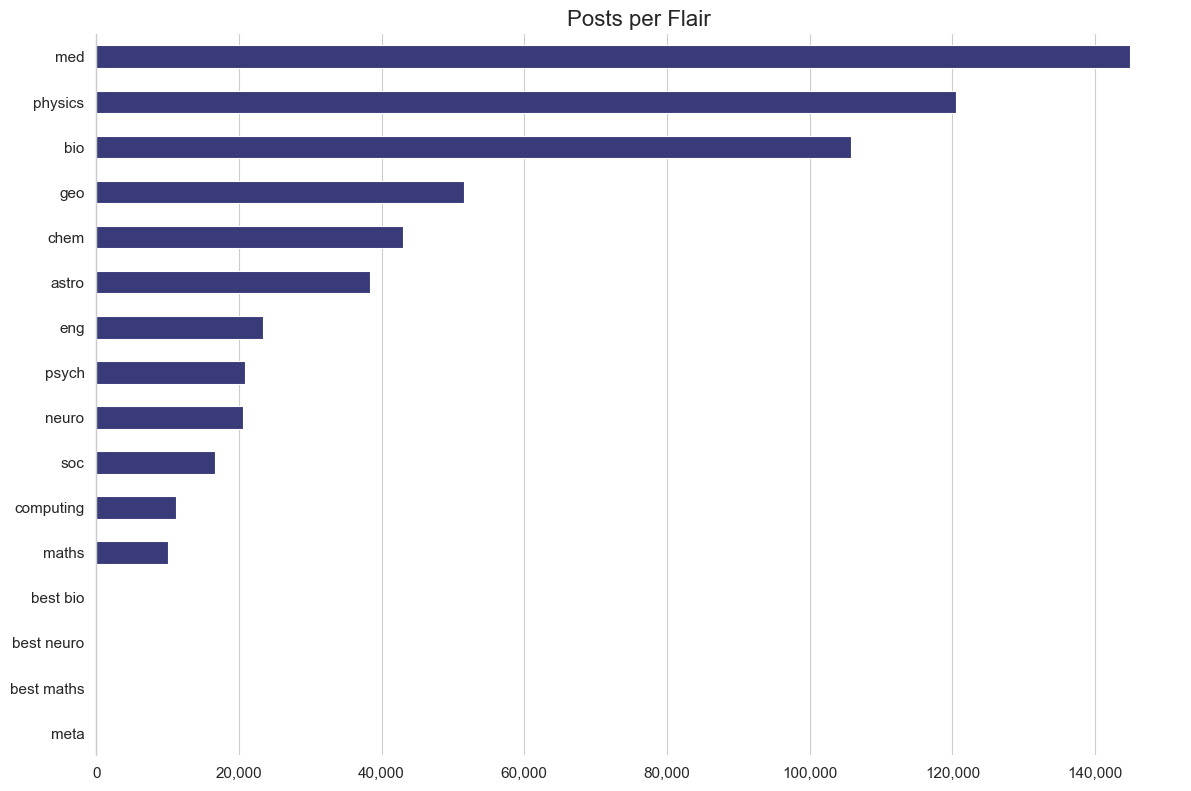

In [13]:
counts = df["link_flair_css_class"].value_counts()
counts = counts.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12,8))
counts.plot(kind="barh", ax=ax, colormap='tab20b')

plt.xlabel("")
plt.ylabel("")
plt.title("Posts per Flair", fontsize=16)
plt.yticks(fontsize=11)
plt.xticks(fontsize=11)

# Format x-axis with commas
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# Despine plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Hide horizontal gridlines
plt.grid(axis="y", visible=False)

plt.tight_layout()

plt.savefig('viz/EDA_posts_per_flair.png', dpi=300)
plt.show()

The distribution of posts across css_classes (which seems to correspond to a high level classification of academic disciplines) shows that medicine, physics and biology are by far the most asked sciences. The categories *meta* and *best ...* each contain only one post. It is not fully clear what these classes are, presumably platform artifacts indicating posts with high upvotes or similar.

In [14]:
counts.sort_values(ascending=False)

link_flair_css_class
med           144820
physics       120508
bio           105754
geo            51540
chem           43008
astro          38409
eng            23315
psych          20827
neuro          20552
soc            16621
computing      11125
maths          10091
best bio           2
best maths         1
best neuro         1
meta               1
Name: count, dtype: int64

## Cleaning & Preprocessing for NLP

In [15]:
df

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09
...,...,...,...,...,...,...,...,...,...
612663,ry6of6,Dr_HanibalLecter,Dentists! I've got a question for you: why do ...,med,Medicine,[removed],2022-01-07 12:49:34,2022,2022-01-07 12:49:44
612664,ry6nvu,matew312,Why did we evolve to have consciousness?,bio,Biology,[removed],2022-01-07 12:48:42,2022,2022-01-07 12:48:52
612665,ry6nle,Unique-horny,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,[removed],2022-01-07 12:48:11,2022,2022-01-07 12:48:22
612666,rwkxsm,jallen11altnagelvin,Would tracing paper be classed as translucent ...,physics,Physics,[removed],2022-01-05 11:37:15,2022,2022-01-05 11:37:26


### Language Detection

In [16]:
df["org_post"] = (
    df["question"].fillna("").str.strip()
    + " "
    + df["description"].fillna("").str.strip()
).str.strip()

In [17]:
def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"

# Create a new column with detected language
df["language"] = df["org_post"].apply(detect_language)
df

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en
...,...,...,...,...,...,...,...,...,...,...,...
612663,ry6of6,Dr_HanibalLecter,Dentists! I've got a question for you: why do ...,med,Medicine,[removed],2022-01-07 12:49:34,2022,2022-01-07 12:49:44,Dentists! I've got a question for you: why do ...,en
612664,ry6nvu,matew312,Why did we evolve to have consciousness?,bio,Biology,[removed],2022-01-07 12:48:42,2022,2022-01-07 12:48:52,Why did we evolve to have consciousness? [remo...,en
612665,ry6nle,Unique-horny,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,[removed],2022-01-07 12:48:11,2022,2022-01-07 12:48:22,Why don't the oceans get saltier over time? Or...,en
612666,rwkxsm,jallen11altnagelvin,Would tracing paper be classed as translucent ...,physics,Physics,[removed],2022-01-05 11:37:15,2022,2022-01-05 11:37:26,Would tracing paper be classed as translucent ...,en


In [18]:
df['language'].unique()

<StringArray>
[     'en',      'no',      'bg',      'da',      'it',      'af',      'ja',
      'ro',      'es',      'sq',      'sl',      'ca',      'fr',      'nl',
      'et',      'ko',      'cy',      'ru',      'pt',      'de',      'hr',
      'uk',      'sk',      'tr',      'id',      'sv',      'fi',      'cs',
      'vi',      'pl',      'ar',      'so',      'tl',      'bn', 'unknown',
      'hu',      'ta',      'lt',      'sw',      'lv',      'hi',      'th',
      'fa',      'te',      'ur',      'ne',   'zh-cn',      'ml',      'el']
Length: 49, dtype: str

In [19]:
# Keep english posts only
df = df[df["language"] == "en"].copy()
df

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en
...,...,...,...,...,...,...,...,...,...,...,...
612663,ry6of6,Dr_HanibalLecter,Dentists! I've got a question for you: why do ...,med,Medicine,[removed],2022-01-07 12:49:34,2022,2022-01-07 12:49:44,Dentists! I've got a question for you: why do ...,en
612664,ry6nvu,matew312,Why did we evolve to have consciousness?,bio,Biology,[removed],2022-01-07 12:48:42,2022,2022-01-07 12:48:52,Why did we evolve to have consciousness? [remo...,en
612665,ry6nle,Unique-horny,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,[removed],2022-01-07 12:48:11,2022,2022-01-07 12:48:22,Why don't the oceans get saltier over time? Or...,en
612666,rwkxsm,jallen11altnagelvin,Would tracing paper be classed as translucent ...,physics,Physics,[removed],2022-01-05 11:37:15,2022,2022-01-05 11:37:26,Would tracing paper be classed as translucent ...,en


### Basic Cleaning of Question and Description

In [20]:
def basic_clean(text):
    if not isinstance(text, str):
        return text

    # Lowercase
    text = text.lower()

    # Normalize Unicode
    text = unicodedata.normalize("NFKC", text)

    # Decode HTML entities
    text = html.unescape(text)

    # Remove elongations
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove Reddit mentions
    text = re.sub(r"/u/\w+|/r/\w+", "", text)

    # Replace newlines + tabs with space
    text = re.sub(r"[\n\r\t]+", " ", text)

    # Remove leftover HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Replace punctuation with whitespace
    text = re.sub(r"[^\w\s-]", " ", text)

    # Replace multiple dashes or underscores
    text = re.sub(r"[-_]{2,}", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_question"] = df["question"].apply(basic_clean)
df['clean_desc'] = df['description'].apply(basic_clean)
df

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed
...,...,...,...,...,...,...,...,...,...,...,...,...,...
612663,ry6of6,Dr_HanibalLecter,Dentists! I've got a question for you: why do ...,med,Medicine,[removed],2022-01-07 12:49:34,2022,2022-01-07 12:49:44,Dentists! I've got a question for you: why do ...,en,dentists i ve got a question for you why do de...,removed
612664,ry6nvu,matew312,Why did we evolve to have consciousness?,bio,Biology,[removed],2022-01-07 12:48:42,2022,2022-01-07 12:48:52,Why did we evolve to have consciousness? [remo...,en,why did we evolve to have consciousness,removed
612665,ry6nle,Unique-horny,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,[removed],2022-01-07 12:48:11,2022,2022-01-07 12:48:22,Why don't the oceans get saltier over time? Or...,en,why don t the oceans get saltier over time or ...,removed
612666,rwkxsm,jallen11altnagelvin,Would tracing paper be classed as translucent ...,physics,Physics,[removed],2022-01-05 11:37:15,2022,2022-01-05 11:37:26,Would tracing paper be classed as translucent ...,en,would tracing paper be classed as translucent ...,removed


### Checking for Duplicates Again
Posts with the same question, description, and author are dropped.

In [21]:
df[['clean_question', 'clean_desc', 'author']].duplicated().sum()

np.int64(6050)

In [22]:
df = df.drop_duplicates(subset=['clean_question', 'clean_desc', 'author'])
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed


### Checking for Meanigfulness of Recurring Descriptions
Most descriptions that occur more than once do not carry information with respect to the question's topic.

In [23]:
counts = df["clean_desc"].value_counts()
counts[counts > 1]

clean_desc
removed                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

### Checking for Meaningfulness of Short Questions and Descriptions

In [24]:
df[
    (df["clean_question"] != "") &
    (df["clean_question"].fillna("").str.split().str.len() < 2)
]["clean_question"]

301            joule-thompson-coefficient
580                              equation
3308                              physics
3320                              biology
3722                            chemistry
                       ...               
575913                  telecomunications
586935    xidifififigogofogififofifjxjxjx
598977                nineteen_characters
600441                              eebis
610578                               hh77
Name: clean_question, Length: 384, dtype: str

In [25]:
df[
    (df["clean_desc"] != "") &
    (df["clean_desc"].fillna("").str.split().str.len() < 3)
]["clean_desc"]

0         removed
1         removed
3         removed
4         removed
5         removed
           ...   
612663    removed
612664    removed
612665    removed
612666    removed
612667    removed
Name: clean_desc, Length: 553640, dtype: str

### Tokenization & Lemmatization

In [26]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# latin_pattern = re.compile(r"^[A-Za-zÀ-ÖØ-öø-ÿ]+$")
# repeat_pattern = re.compile(r"(.)\1{2,}")

def clean_doc(doc):
    tokens = []

    for token in doc:

        if token.is_space or token.is_punct:
            continue

        if token.is_stop:
            continue

        lemma = token.lemma_.lower()

        if len(lemma) < 2:
            continue

        tokens.append(lemma)

    return tokens

docs = nlp.pipe(df["clean_question"].astype(str), batch_size=1000, n_process=-1)
df["question_tokens"] = [clean_doc(doc) for doc in docs]

docs = nlp.pipe(df["clean_desc"].astype(str), batch_size=1000, n_process=-1)
df["desc_tokens"] = [clean_doc(doc) for doc in docs]

df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[remove]
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[remove]
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[commonly, know, fact, metal, oxidize, possibl...",[]
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[remove]
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[remove]


In [27]:
df[
    (df["desc_tokens"].str.len() > 0) &
    (df["desc_tokens"].str.len() < 2)
]["desc_tokens"]

0         [remove]
1         [remove]
3         [remove]
4         [remove]
5         [remove]
            ...   
612663    [remove]
612664    [remove]
612665    [remove]
612666    [remove]
612667    [remove]
Name: desc_tokens, Length: 553697, dtype: object

In [28]:
desc_counts = df["desc_tokens"].apply(tuple).value_counts()
desc_counts[desc_counts > 2]

desc_tokens
(remove,)                552005
()                        17650
(delete,)                  1496
(title,)                     41
(thank,)                     14
(title, say)                 14
(curious,)                   10
(thank, advance)              7
(example,)                    7
(basically, title)            4
(like,)                       4
(talk,)                       3
(physics,)                    3
(edit, thank, answer)         3
(look, like)                  3
(biology,)                    3
(source,)                     3
(pretty, title)               3
Name: count, dtype: int64

#### Remove meaningless descriptions

In [29]:
bad_tokens = desc_counts[desc_counts > 2].index
df["desc_tokens"] = df["desc_tokens"].apply(
    lambda x: [] if isinstance(x, list) and len(x) < 5 and tuple(x) in bad_tokens else x
)
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[]
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[]
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[commonly, know, fact, metal, oxidize, possibl...",[]
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[]
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[]


#### Remove Duplicates AGAIN

In [30]:
df["q_tuple"] = df["question_tokens"].apply(tuple)
df["d_tuple"] = df["desc_tokens"].apply(tuple)

df[['q_tuple', 'd_tuple', 'author']].duplicated().sum()

np.int64(3640)

In [31]:
df = df.drop_duplicates(subset=["q_tuple", "d_tuple", "author"])
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[],"(time, define, big, bang)",()
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",()
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[commonly, know, fact, metal, oxidize, possibl...",[],"(commonly, know, fact, metal, oxidize, possibl...",()
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",()
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",()


### Concatenate Question & Description Tokens

In [41]:
df['post_tokens'] = df['question_tokens'] + df['desc_tokens']
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[],"(time, define, big, bang)",(),"[time, define, big, bang]"
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific, explanation, atmospher..."
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[commonly, know, fact, metal, oxidize, possibl...",[],"(commonly, know, fact, metal, oxidize, possibl...",(),"[commonly, know, fact, metal, oxidize, possibl..."
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]"
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research, project, sho..."


## Save Preprocessed Data

In [51]:
# Save lemmatized df to pickle file
df.to_pickle("data/preprocessed_data.pkl")